Make sure modules reload:

In [1]:
%load_ext autoreload
%autoreload 2

Results and progress files are stored in a directory. Simulations (after potentially changing some parameters etc) are restarted from them and update them:

In [73]:
outputFolderName="notebooks/example_evo"
from run_main import run

To start from scratch remove the directory:

In [74]:
!rm -rf notebooks/example_evo

/bin/bash: /home/adam/miniconda3/envs/celoc_env/lib/libtinfo.so.6: no version information available (required by /bin/bash)


Some basic parameters are passed as command line arguments which are stored in a python dict object:

In [75]:
args = dict(
    simduration=50, #duration of simulation run
    simtransient=0, #transient of simulation run
    modelFolder="Worm2D", #folder containing the compiled C++ binary code
    outputFolderName=outputFolderName, #output folder
    overwrite=True, #allow overwrite of output folder 
    checkPointInterval=5, #write the checkpoint file every five generations 
    doOrigMuscInput=False, #use standardized muscle connecitiviy
    doOrigSRInput=False, #use standardized stretch receptors 
    randInitState=False, #use fixed initial conditions
    doTestRun=True, #run a single simple simulation
)

Parameters can be added to the args dict object in the standard python way. Here 'doEvol' tells us to run an optimization using the genetic algorithm. 'maxGens' tells us how many generations to run. Evolutions start from existing parameter files in the directory, so it is possible to run a few generations, examine results and then restart from the final state if the model does not seem to be optimized as desired. This also includes potentially changing optimization parameters and functions. The 'popSize' is the number of individual phenotypes simulated in a single generation. Simulations are performed in parallel so it is sensible to set this parameter to at least the number of cpu cores you have available. 'modelName' tells us which worm model to run. There are several 'hard-coded', 'supplied' models, including 'W2D18', 'W2D21', and 'W2DCE'. These perform simulations of existing published c.elegans models which employ the worm body simulation utilized here. These models include particular configurations of cells, ventral nerve cord, nervous system to muscle connectivity and stretch receptors etc. Parameters are further fine tuned by the genetic algorithm. Once a simulation is run with one of them, a JSON parameter file is created in the directory. The JSON file contains all the model and evolutionary algorithm parameters. If desired further simulations can start from the generic 'W2DSR' model which is initialized entirely from the JSON parameter file. This enables users to configure all aspects of the model, including adding and removing cells, changing parameters and connectivity, selecting which parameters will be 'evolvable' via the genetic algorithm, as well as particulars of the optimization and sensory environment etc. Here we are starting with the 'W2D18' model. 'evoType' selects the particular optimization function to utilize. Different optimization functions select for different properties, such as locomotion speed, oscillation frequency, movement up a chemical gradient etc. The command 'run(**args)' starts the simulation and evolves the current worm model for a further 10 (maxGens) generations every time it is run. 

Further generations to be added: 10
Directory 'notebooks/example_evo' created successfully.
['Worm2D/main_osc', '--randomInitialState', '0', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--doTestRun', '1', '-R', '929921', '-p', '66', '-d', '50', '-t', '10', '--maxgens', '10', '-sd', '50', '-st', '0', '--doevol', '1', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_evo', '--modelname', 'W2D18', '--domusc', '0', '-docpt', '1', '--evoType', 'Evo18']
evotype Evo18
docpt 1
const from default with size 30
jsonfile notebooks/example_evo/worm_data_evo.json
jsonfile notebooks/example_evo/worm_data_evo.json
simrandseed 929921
running simulation sim

Loading activity data from: notebooks/example_evo/act.dat
Loading curvature data from: notebooks/example_evo/curv.dat
Loading body position data from: notebooks/example_evo/body.dat
Saved plot image to: notebooks/example_evo/ExampleActivity.png
Simulation
0.0
60.0
120.0
180.0
240.0
300.0
cell ind is  0
cell ind i

/home/adam/uclwork/CE_locomotion/load_data.py:123: RuntimeWarning: divide by zero encountered in log
  evol_data_diff_131 = sign(evol_data_diff_13[1:]) * np.log(


Saved plot image to: notebooks/example_evo/EvolutionHistory.png
Saved plot image to: notebooks/example_evo/EvolutionHistoryMax.png
Saved plot image to: notebooks/example_evo/EvolutionHistoryMult.png
(11, 4)
Saved plot image to: notebooks/example_evo/FitnessHist.png
Evolvable
value
0
name
checkDict
['NS_biases', 'NS_biases', 'NS_taus', 'NS_taus', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ElecWei', 'NS_ElecWei', 'NS_ElecWei', 'NS_ElecWei', 'SR_SRvncgain', 'VNC 18_D_V', 'VNC 18_D_V', 'NS_biases', 'NS_biases', 'NS_taus', 'NS_taus', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ElecWei', 'NS_ElecWei', 'SR_SRheadgain', 'VNC 18_D_V', 'VNC 18_D_V']
(11, 30)
(11, 30)
(11, 30)
(11, 30)
['NS_ChemWei', 'NS_ElecWei', 'NS_biases', 'NS_taus', 'SR_SRheadgain', 'SR_SRvncgain', 'VNC 18_D_V']
Saved plot image to: notebooks/example_evo/Evolution_averages_redo.png
Saved plot image to: notebooks/example_evo/Evolution_averages_redo_2.png


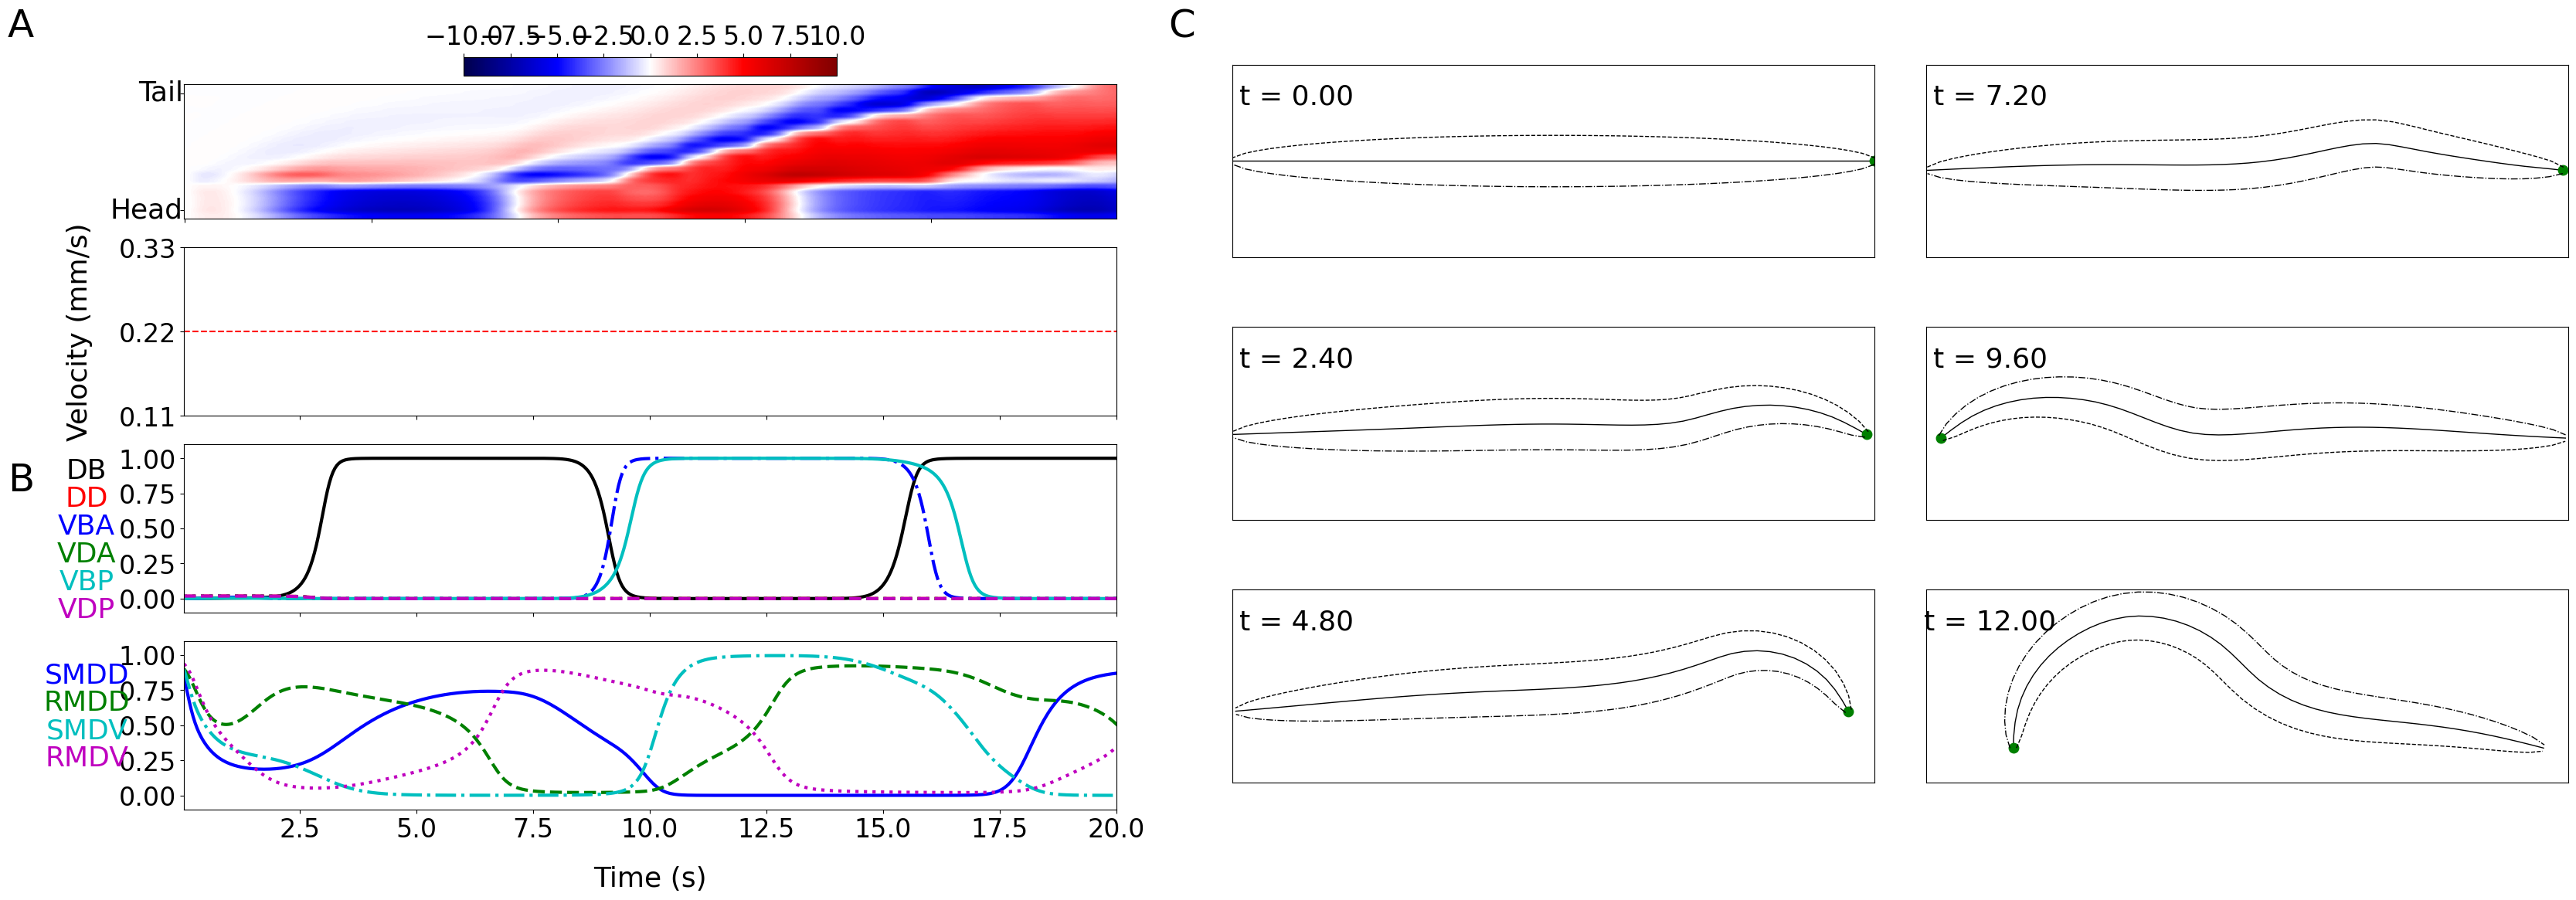

In [76]:
args['RandSeed']= 929921 #if random seed is not set, one will be generated
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args['popSize']=66 #population size for optimization
args['modelName']="W2D18" #the initial code generated model
args['evoType']="Evo18" #the optimization function
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)

After a simulation has been performed the output folder contains various files. These files are updated every time the code is run and should be reloaded after every run in this jupyter notebook to view the most recent version. The fitness.dat file shows the phenotype fitness history for the generations so far. The first column is the generation number, the second the fitness of the best phenotype, the third the average fitness of the population and the fourth the standard deviation of the population fitness:

In [118]:
with open(outputFolderName + '/fitness.dat') as f:
    print(f.read())

0.0 0.01782540616 0.001506947114 1.699302981e-05
1.0 0.01782540616 0.001899018247 2.104124326e-05
2.0 0.01782540616 0.002274629803 2.328140641e-05
3.0 0.0192367713 0.003026127707 2.844037975e-05
4.0 0.01949979181 0.003695736599 3.915042882e-05
5.0 0.02674603177 0.003747407534 4.192700805e-05
6.0 0.1157231263 0.006343121233 0.0002390012878
7.0 0.1157231263 0.006551668761 0.0002555292882
8.0 0.1157231263 0.00804808427 0.0004166820774
9.0 0.1343741316 0.01007212705 0.0006772185986
10.0 0.1343741316 0.01118000832 0.0007991899581
11.0 0.1343741316 0.01118000832 0.0007991899581
12.0 0.1544695378 0.01531791835 0.001292445584
13.0 0.1805887419 0.02192674541 0.002016712251
14.0 0.1805887419 0.017179997 0.001700205428
15.0 0.1805887419 0.01910656941 0.00198939689
16.0 0.1805887419 0.01632183357 0.001666666412
17.0 0.1818420356 0.01730543671 0.001836030029
18.0 0.1818420356 0.01984509148 0.002047870324
19.0 0.2411809832 0.02843975925 0.003705864351
20.0 0.2411809832 0.02389629475 0.0031813171
21.

Display a time series of simulation results of current best phenotype. The transient and duration time intervals for this are set with the parameters 'simtransient' and 'simduration':

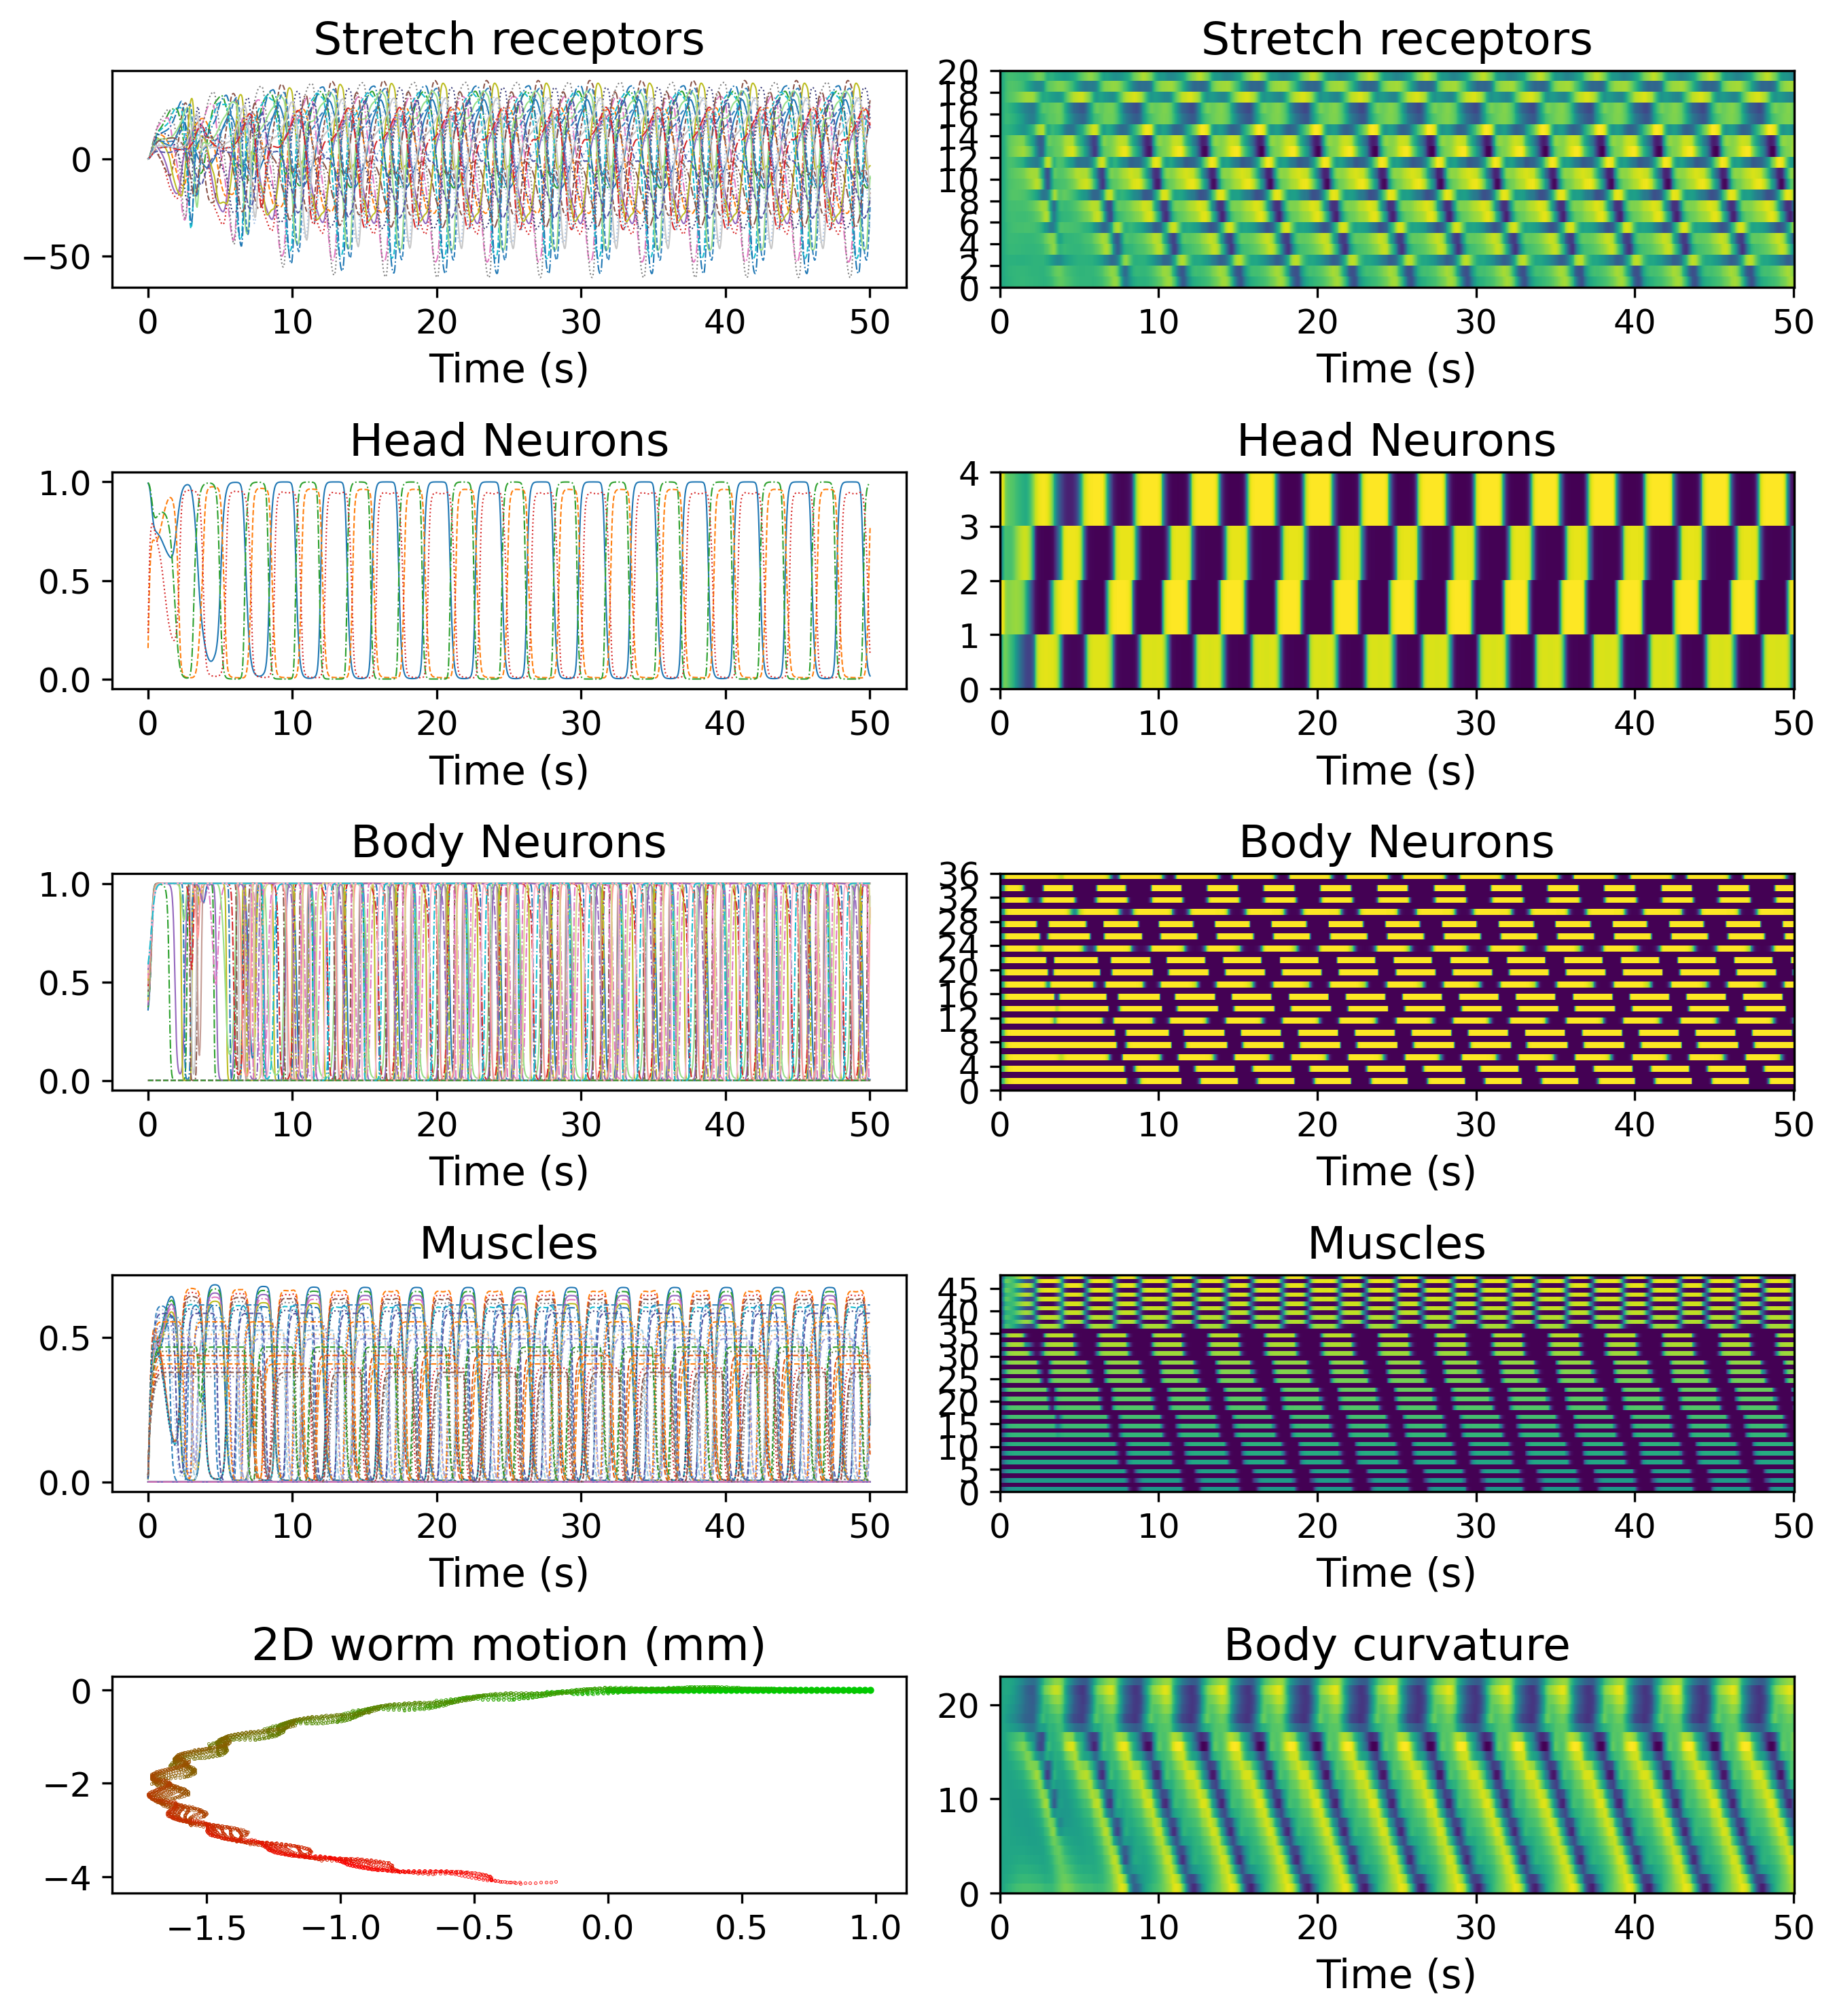

In [119]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/ExampleActivity.png')

Display worm motion in larger plot:

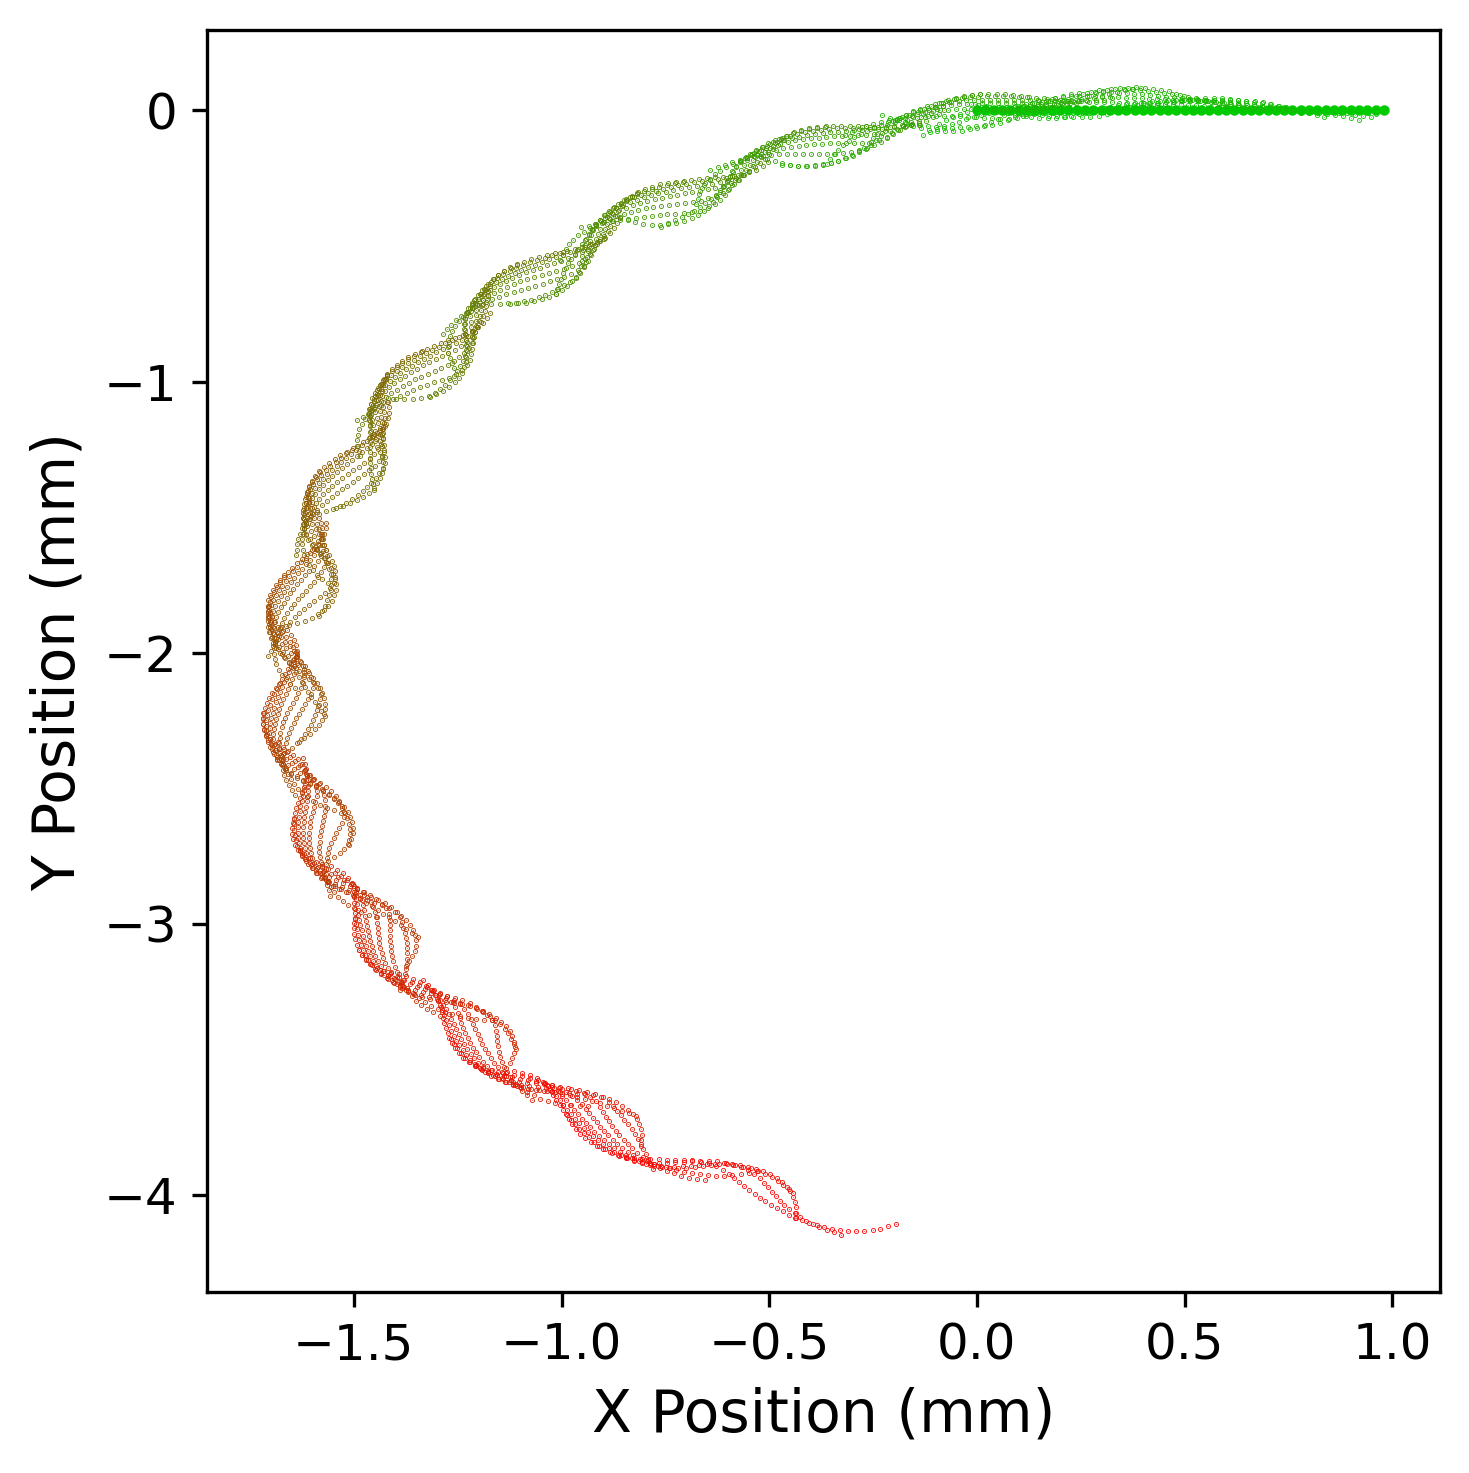

In [120]:
Image(filename=outputFolderName + '/Motion.png')

When the genetic algorithm optimization is performed some model parameters are fined tuned to produce a particular behaviour for the phenotype. The following figure (top left panel) shows how the fitness, (between zero and unity) in log scale, for the best phenotype in the population and the population average phenotype varies over successive generations. The other five panels show how the values of the evolvable model parameters vary over successive generations. In the current model there are 30 such parameters (see bottom right panel). For example there are ten parameters associated with chemical connection weights in the nervous system (denoted NS_ChemWei), two parameters associated with the stretch receptor gains (SR_SRvncgain, SR_SRheadgain) and four associated with the VNC nervous system to muscle connectivity structure (denoted VNC 18_D_V). The figure shows their actual values (top right), percent change from the intial state (middle left), signed log of the percent change (bottom left) all averaged across the whole population. The percent change values for the best phenotype is also shown (middle right).

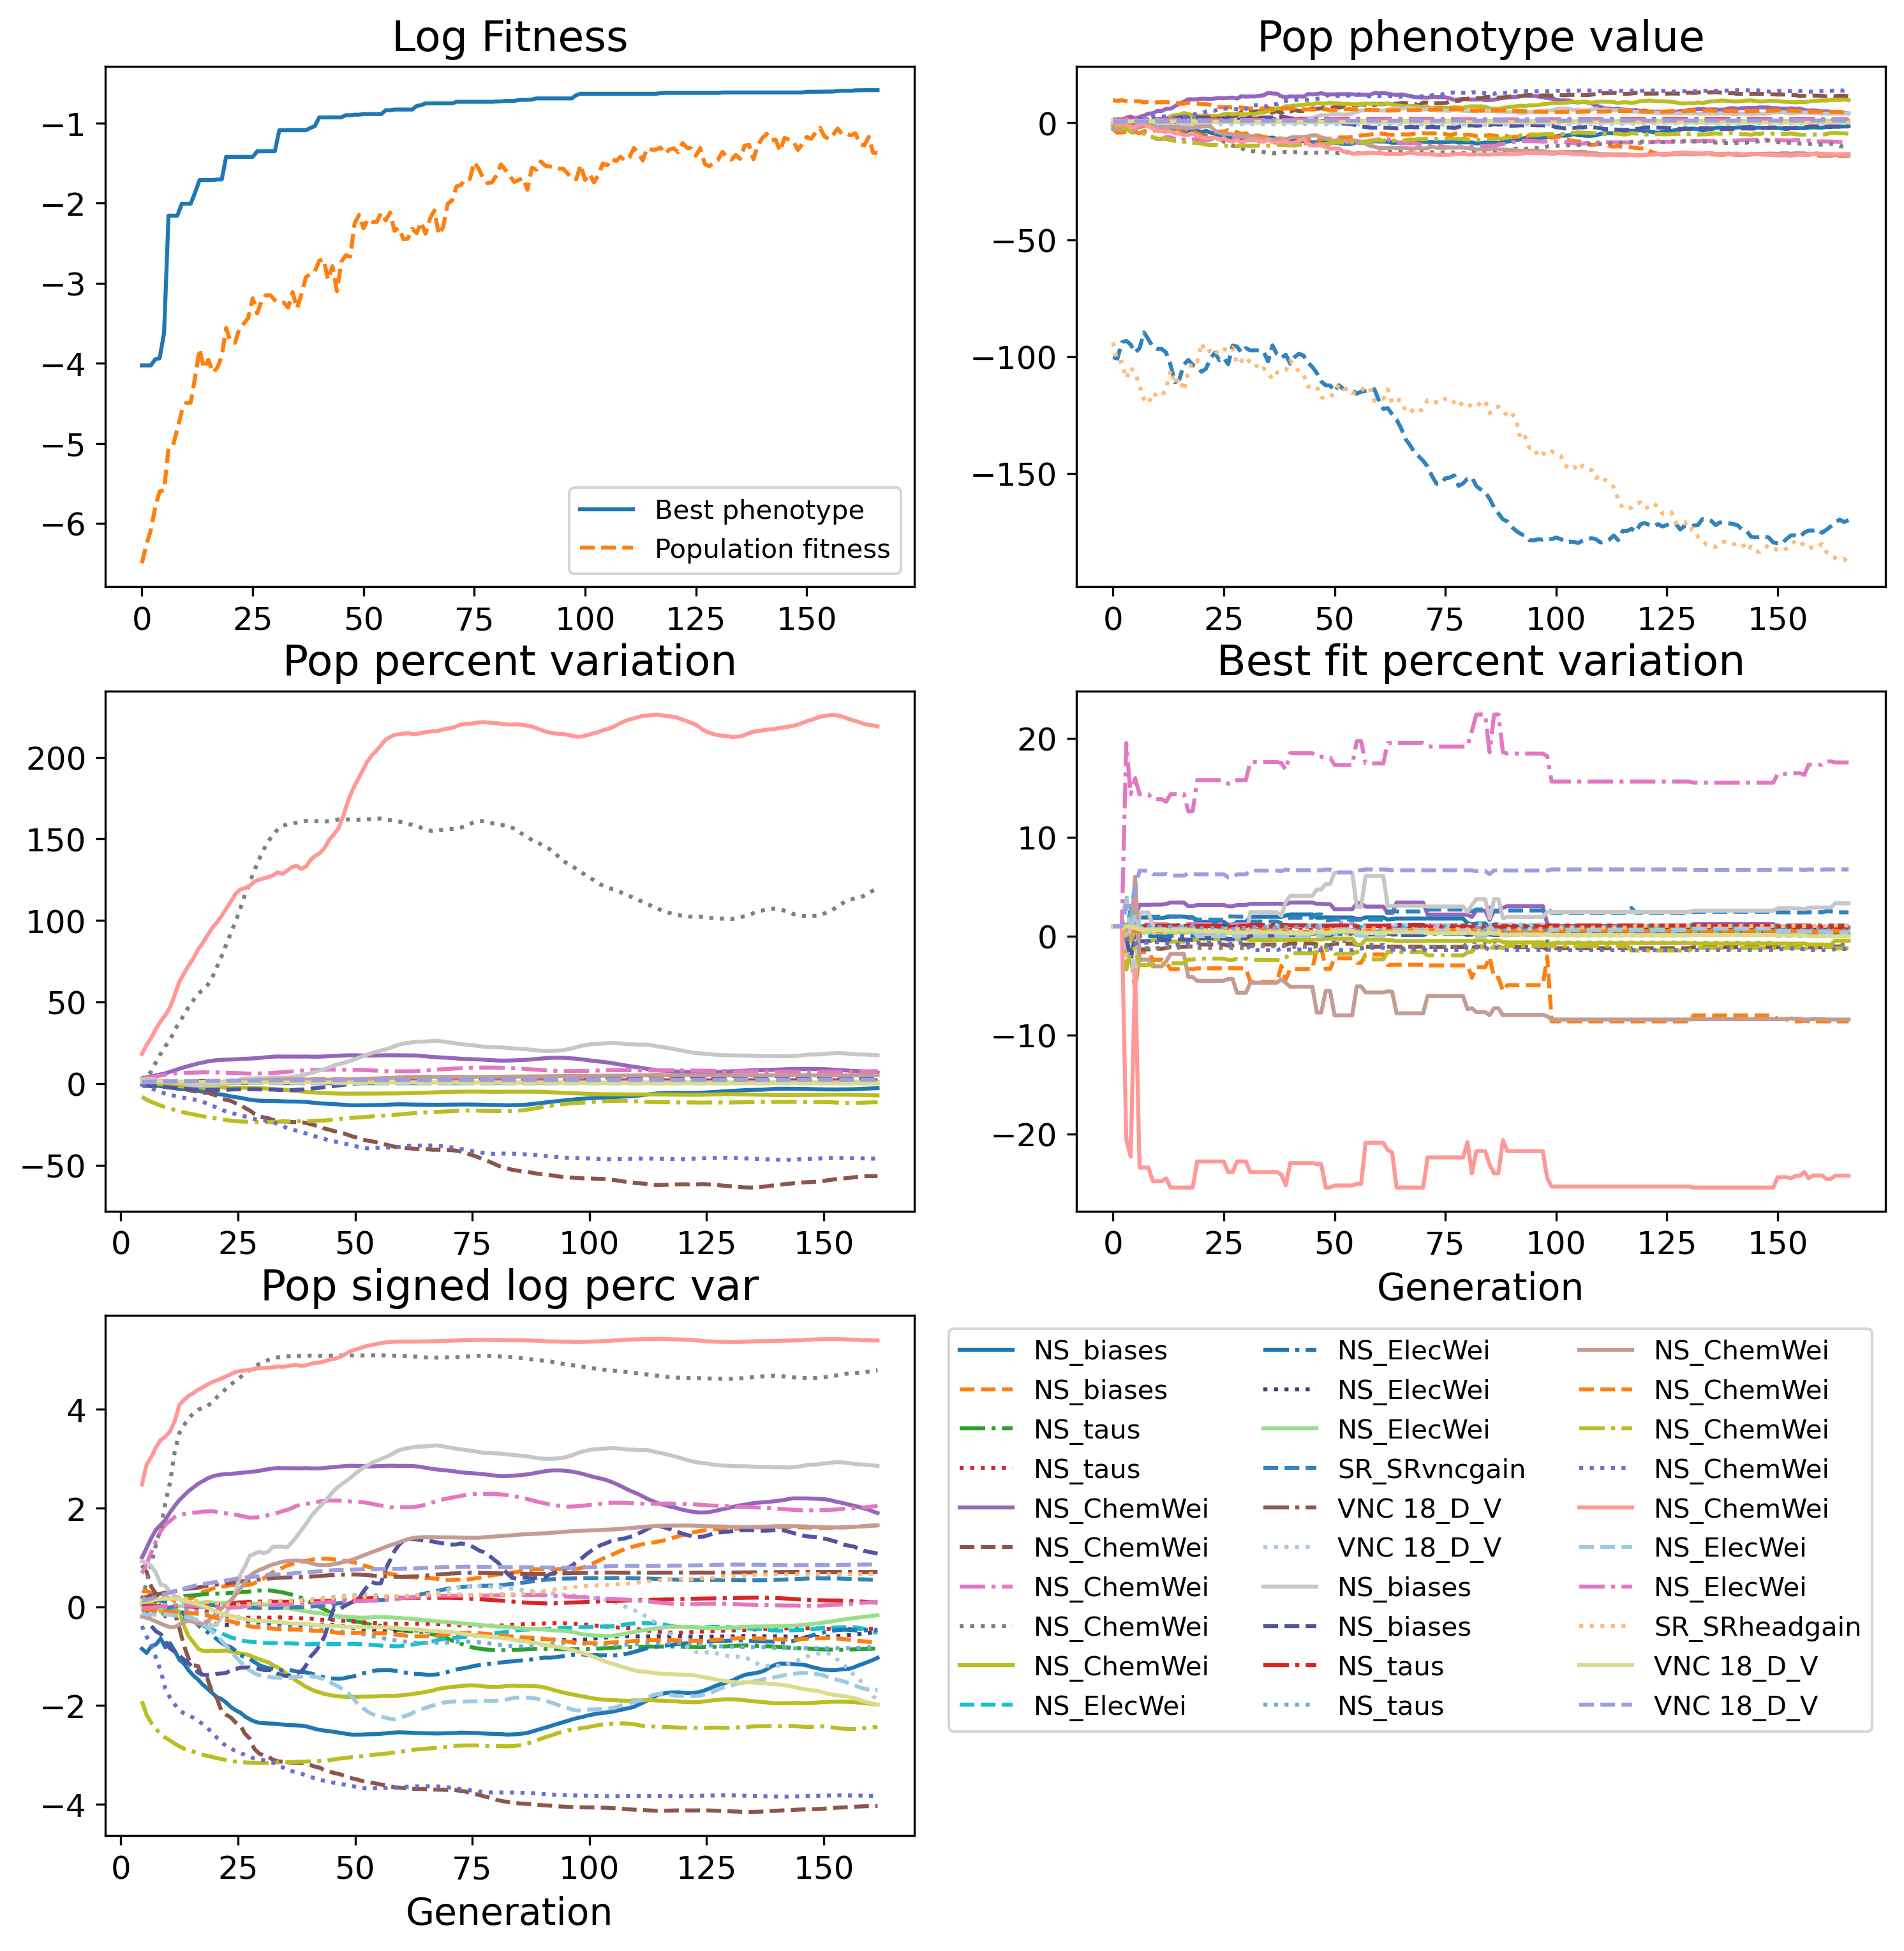

In [121]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Gridfig.png')

For simpler visualization we also plot the evolution history for these evolvable parameters averaged into similar type classes. For example all ten NS_ChemWei parameters are averaged together.

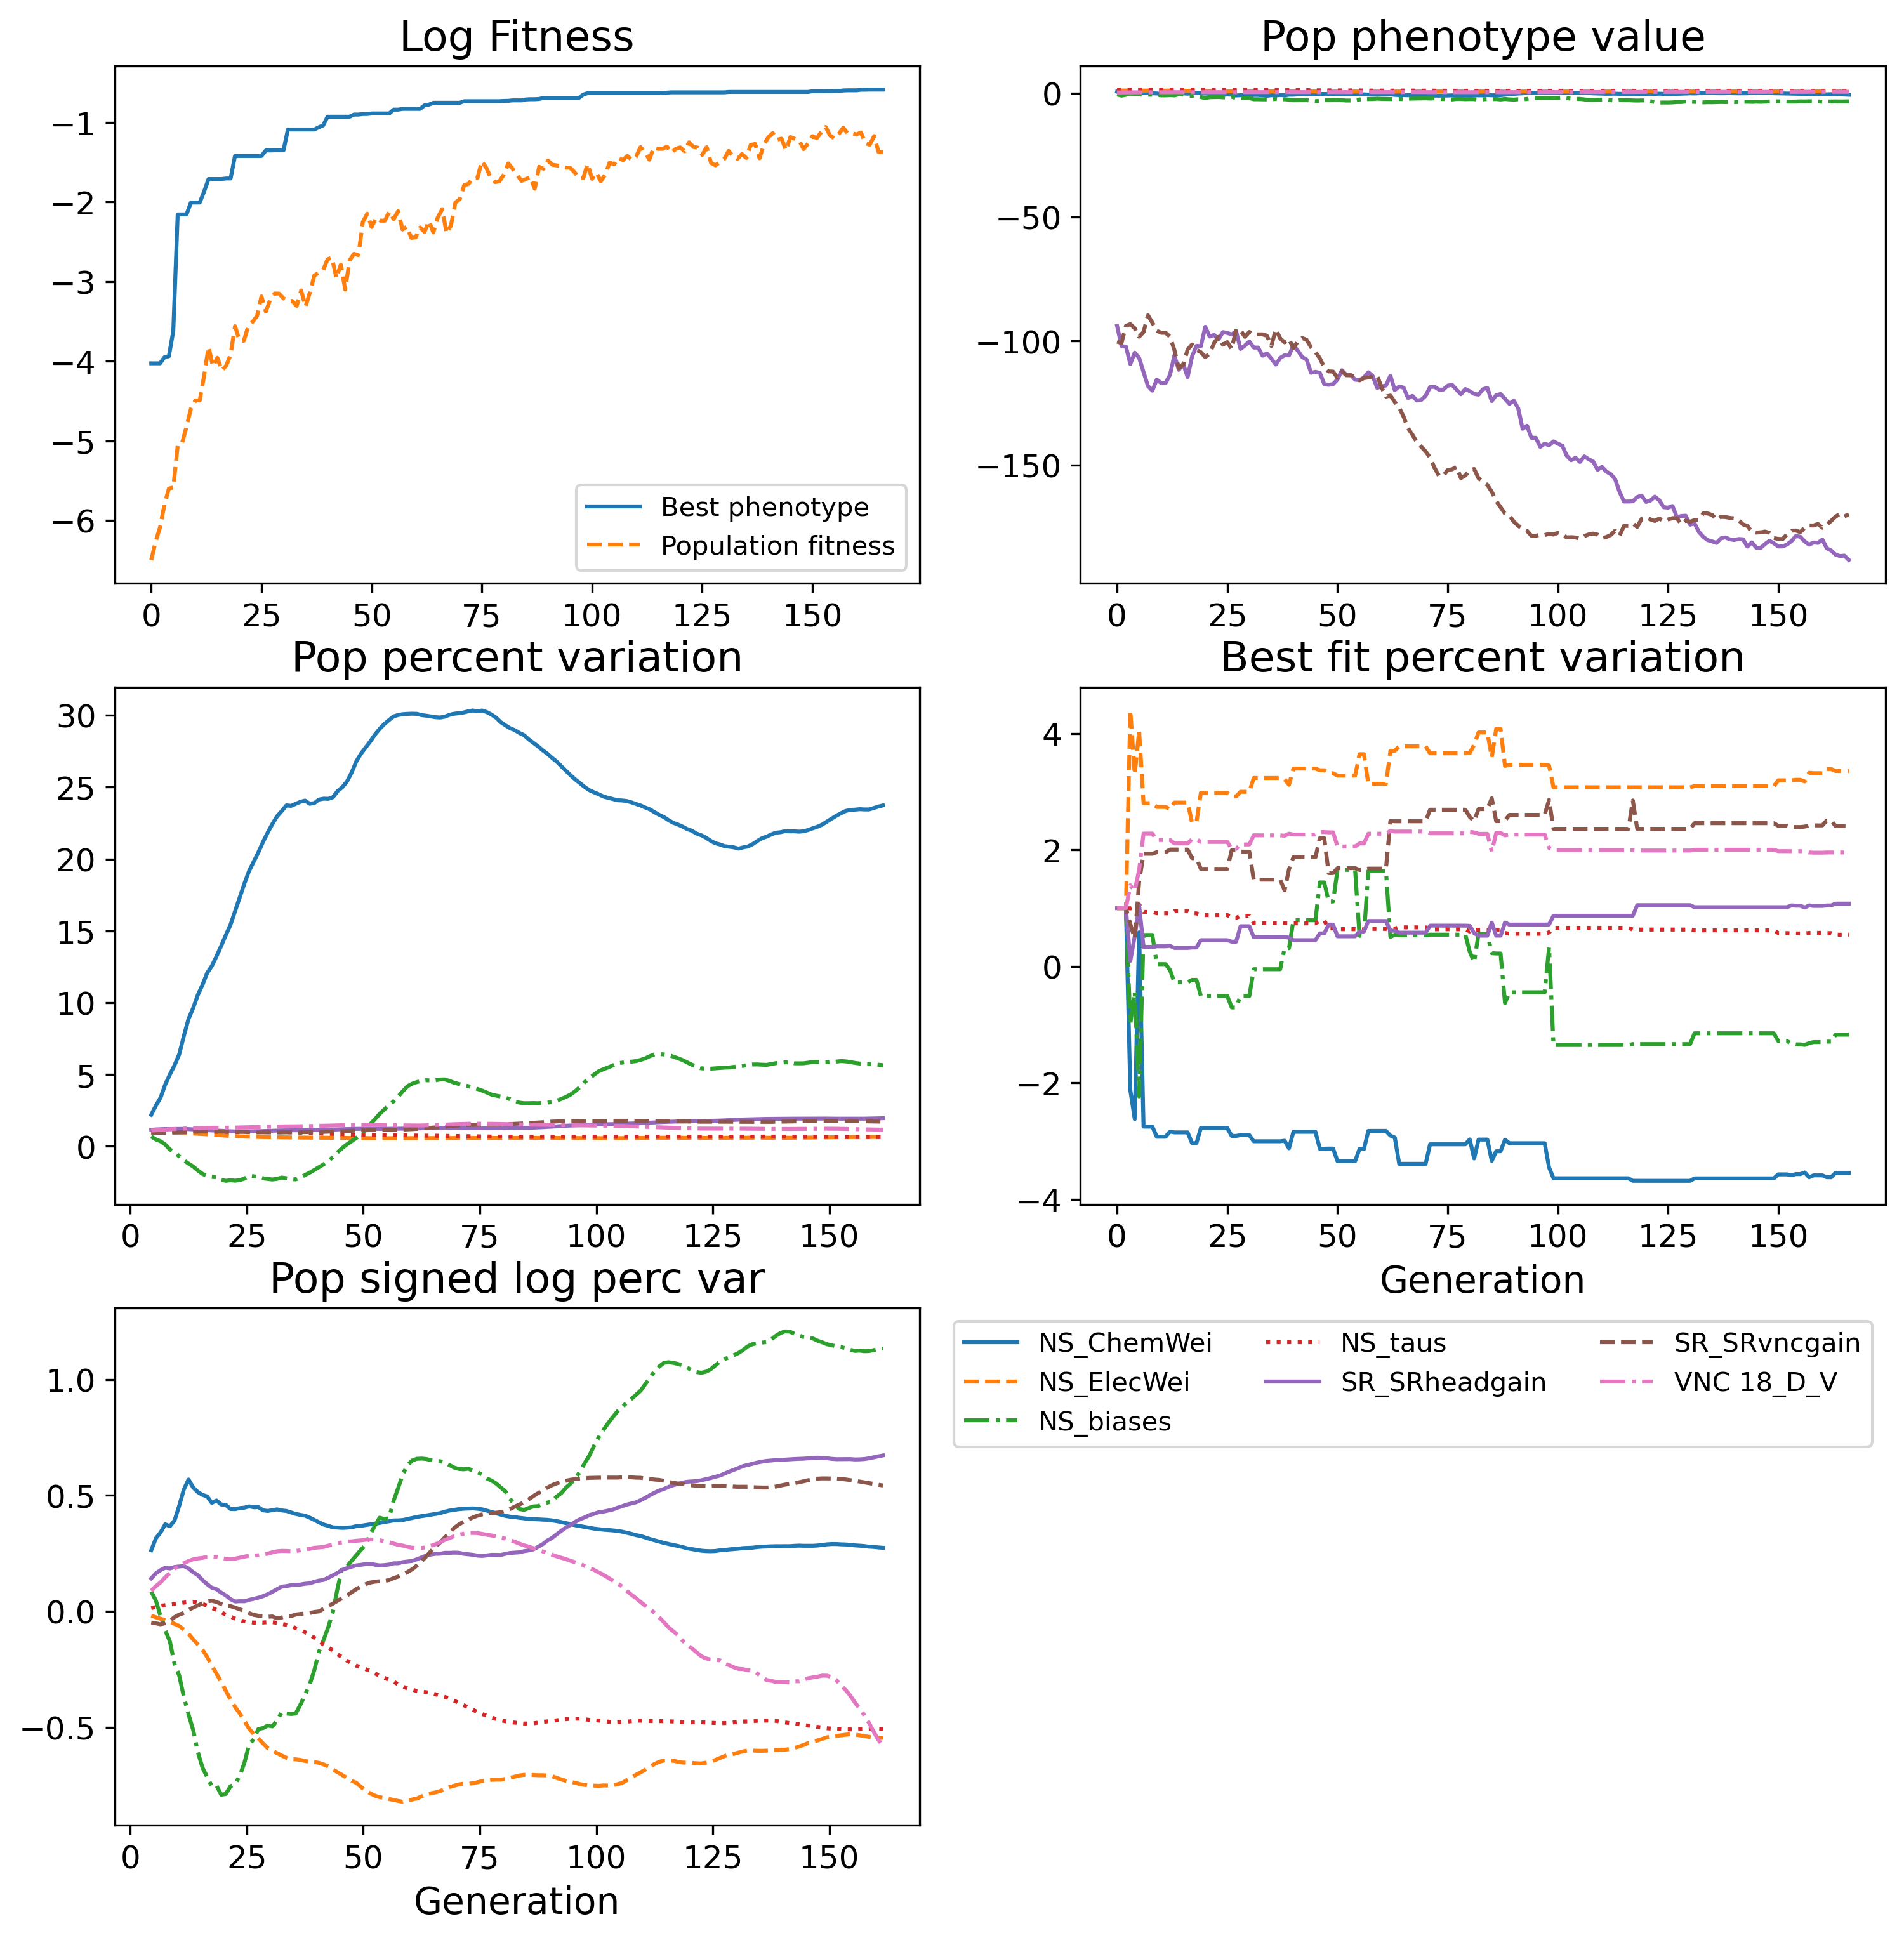

In [122]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Gridfig_av.png')

We also plot the current and initial values for each of the evolvable parameters, and their percent variations.

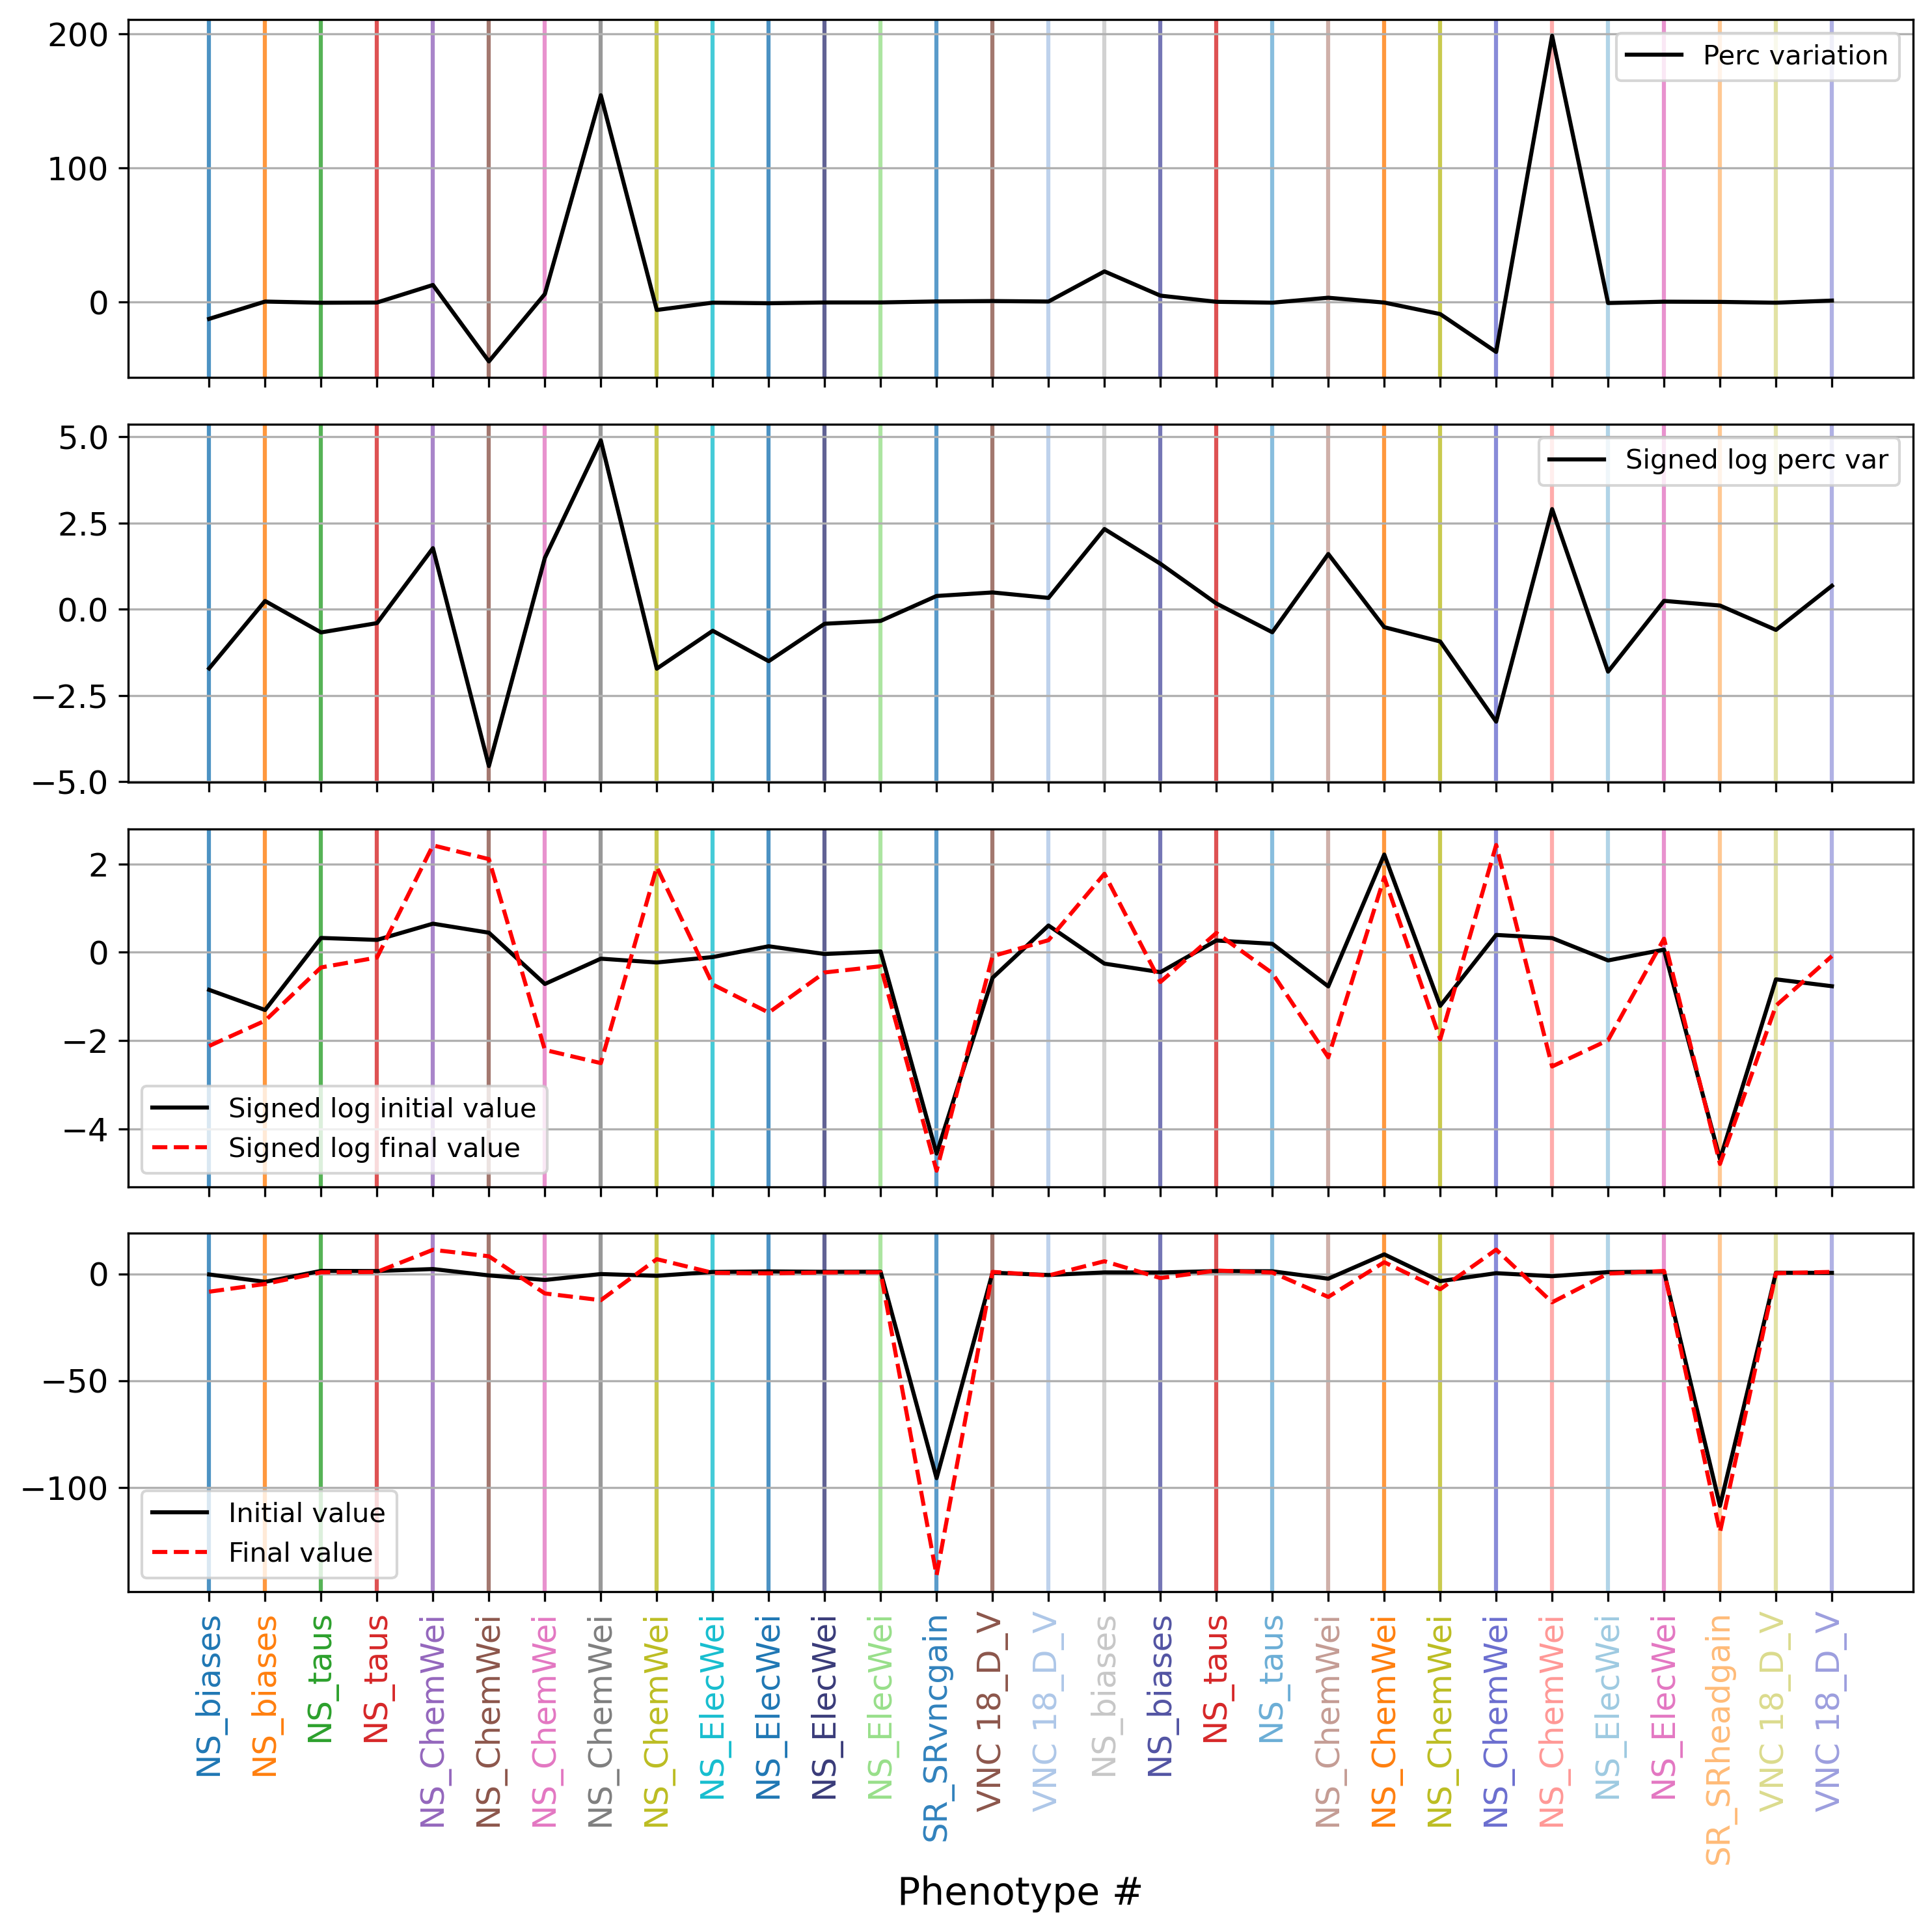

In [108]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Evolution_averages_redo_2.png')

And similarly for their group average values:

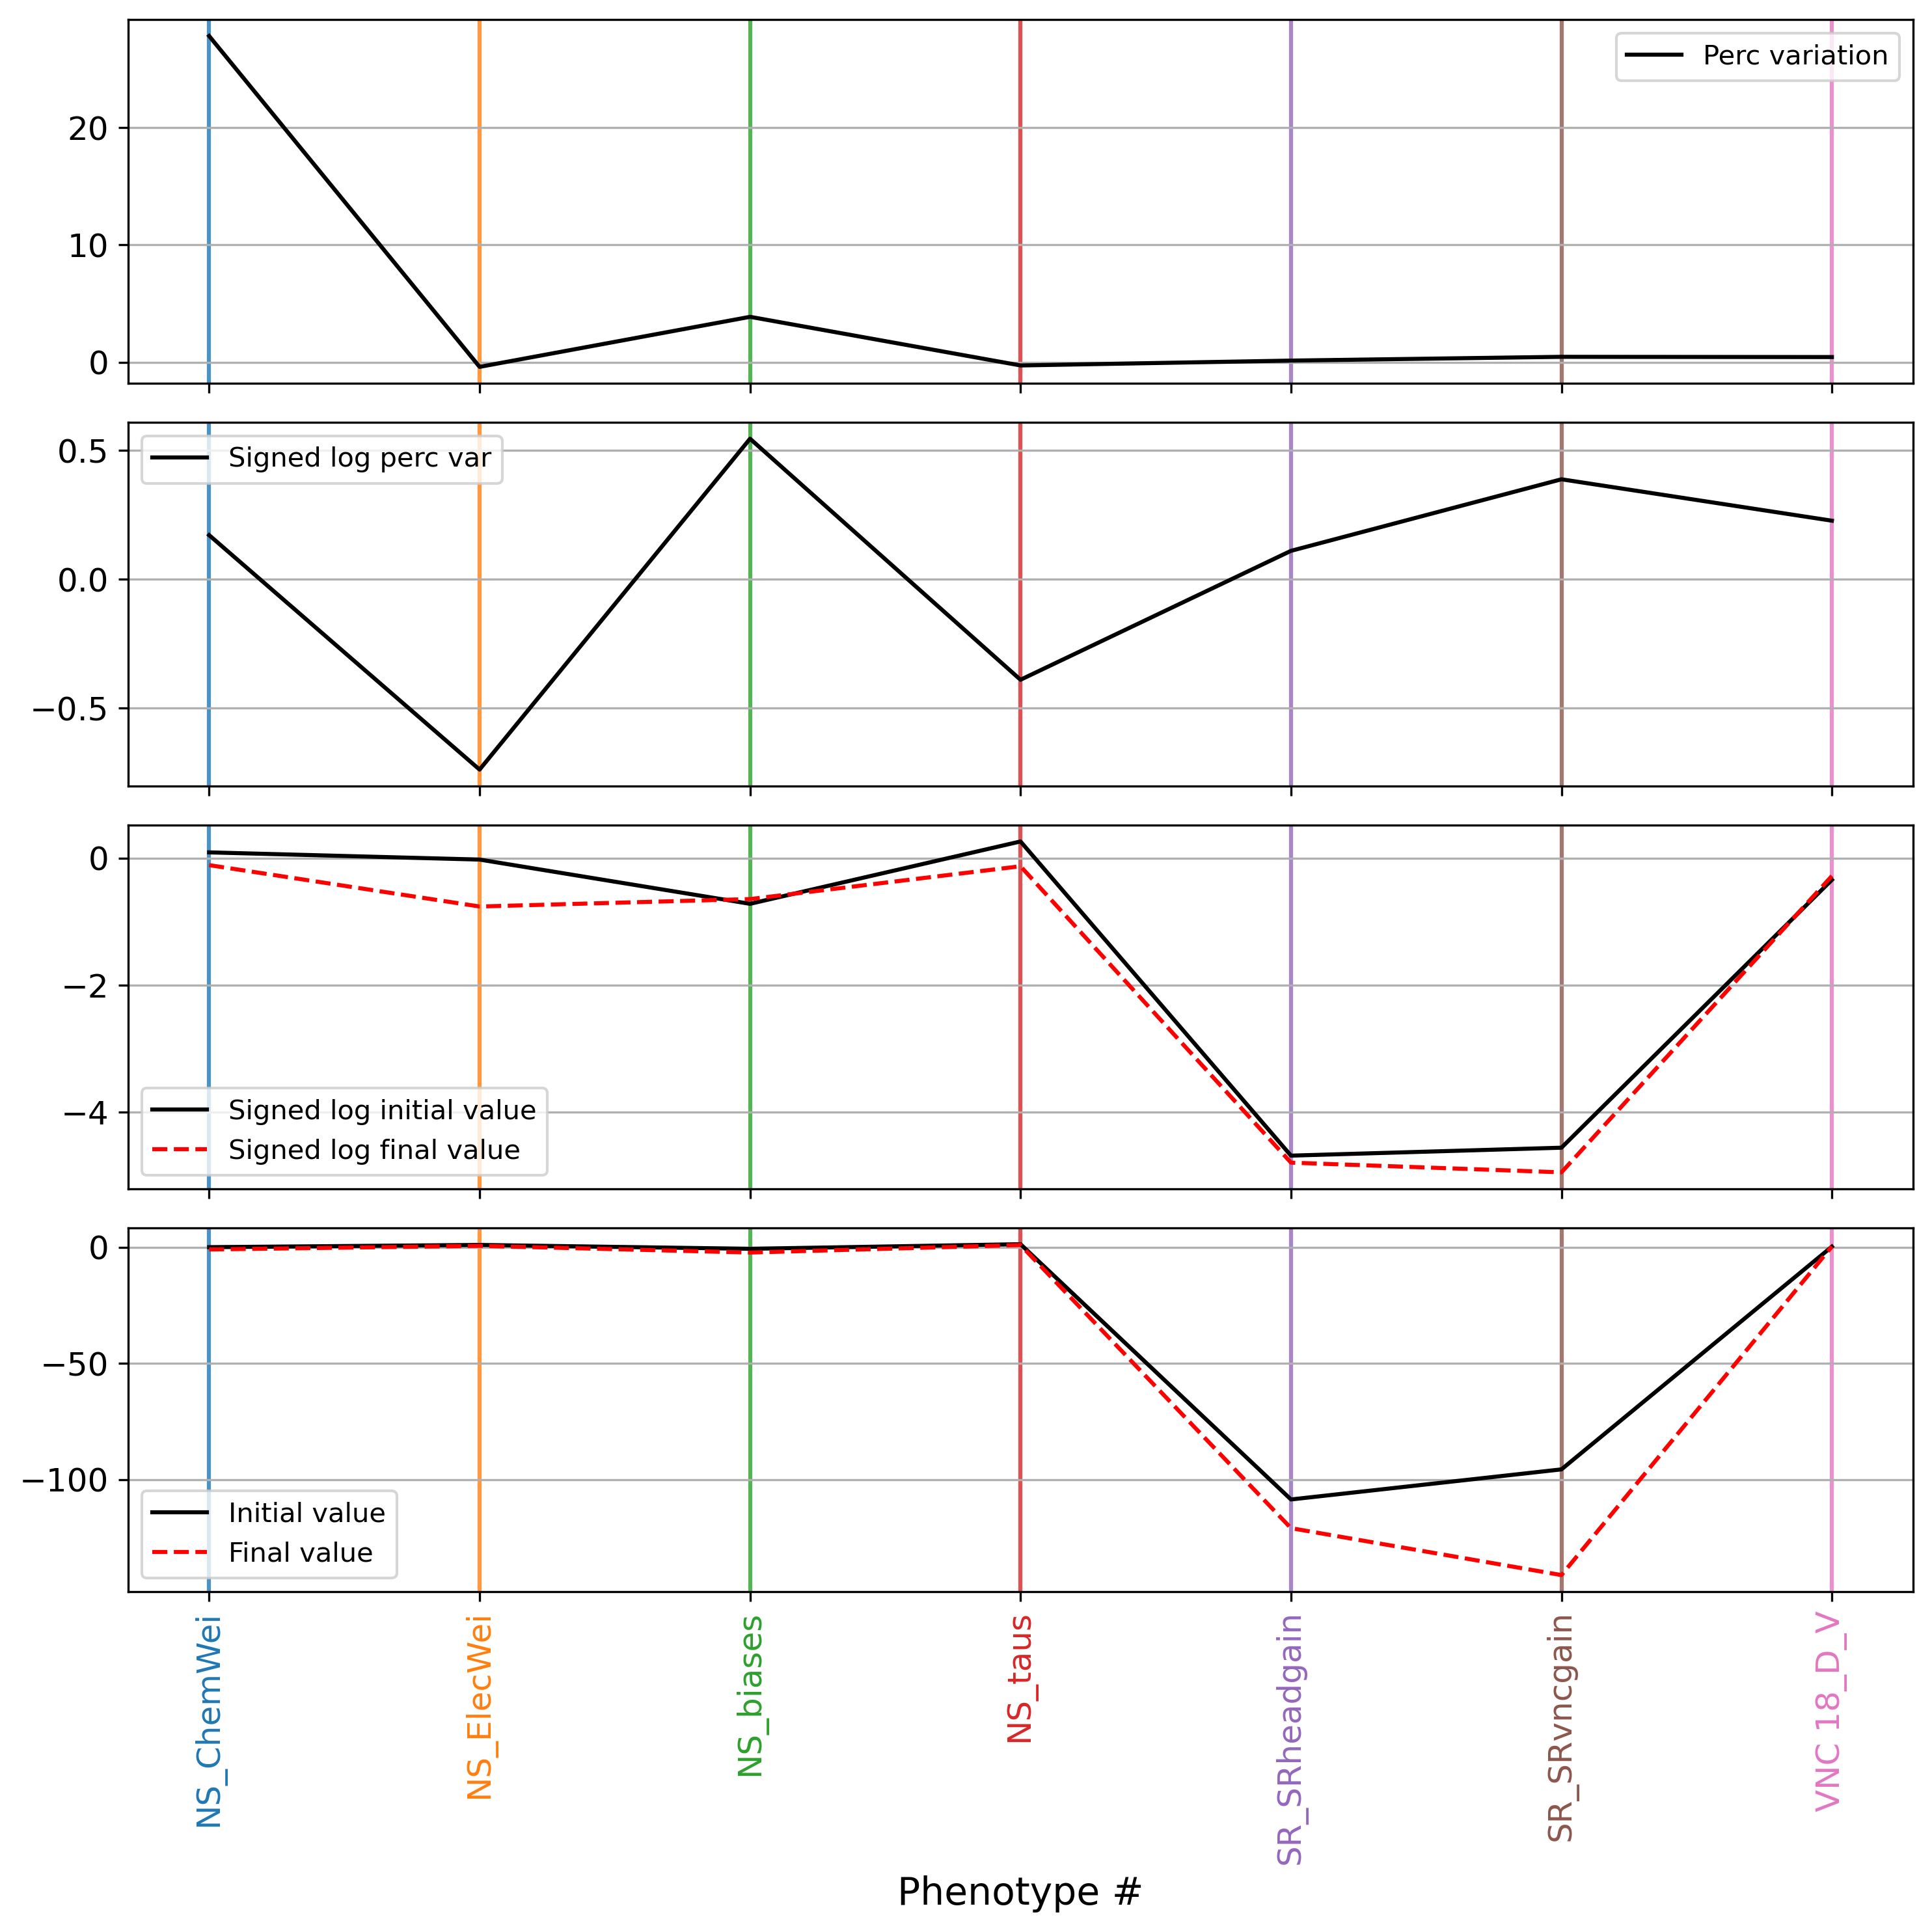

In [109]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Evolution_averages_redo.png')

If the 'evoAvLen' parameter is set, a moving averaged of the parameter values will be performed before plotting. However this will only take effect once another simulation has been performed.

In [85]:
args['evoAvLen']=10 #plot moving average of evolution history figures  

Run the evolution for a further twenty generations. This can be done multiple times. Each time the above results will need to be reloaded in this jupyter notebook. 

Further generations to be added: 50
Directory 'notebooks/example_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
['Worm2D/main_osc', '--randomInitialState', '0', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--doTestRun', '1', '-R', '929921', '-p', '66', '-d', '50.0', '-t', '10.0', '--maxgens', '50', '-sd', '50', '-st', '0', '--doevol', '1', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_evo', '--modelname', 'W2D18', '--domusc', '0', '-docpt', '1', '--evoType', 'Evo18']
jsonfile notebooks/example_evo/worm_data_worm.json
evotype Evo18
docpt 1
setFromCPT2 notebooks/example_evo/search.cpt
Resuming search
jsonfile notebooks/example_evo/worm_data_evo.json
jsonfile notebooks/example_evo/worm_data_evo.json
simrandseed 929921
running simulation sim

Loading activity data from: notebooks/examp

/home/adam/uclwork/CE_locomotion/load_data.py:121: RuntimeWarning: divide by zero encountered in log
  evol_data_diff_11 = sign(evol_data_diff_1) * np.log(np.abs(evol_data_diff_1))
/home/adam/uclwork/CE_locomotion/load_data.py:123: RuntimeWarning: divide by zero encountered in log
  evol_data_diff_131 = sign(evol_data_diff_13[1:]) * np.log(


Saved plot image to: notebooks/example_evo/EvolutionHistory.png
Saved plot image to: notebooks/example_evo/EvolutionHistoryMax.png
Saved plot image to: notebooks/example_evo/EvolutionHistoryMult.png
(167, 4)
Saved plot image to: notebooks/example_evo/FitnessHist.png
Evolvable
value
0
name
checkDict
['NS_biases', 'NS_biases', 'NS_taus', 'NS_taus', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ElecWei', 'NS_ElecWei', 'NS_ElecWei', 'NS_ElecWei', 'SR_SRvncgain', 'VNC 18_D_V', 'VNC 18_D_V', 'NS_biases', 'NS_biases', 'NS_taus', 'NS_taus', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ElecWei', 'NS_ElecWei', 'SR_SRheadgain', 'VNC 18_D_V', 'VNC 18_D_V']
(167, 30)
(167, 30)
(167, 30)
(167, 30)
['NS_ChemWei', 'NS_ElecWei', 'NS_biases', 'NS_taus', 'SR_SRheadgain', 'SR_SRvncgain', 'VNC 18_D_V']
Saved plot image to: notebooks/example_evo/Evolution_averages_redo.png
Saved plot image to: notebooks/example_evo/Evolution_averages_redo_2.png


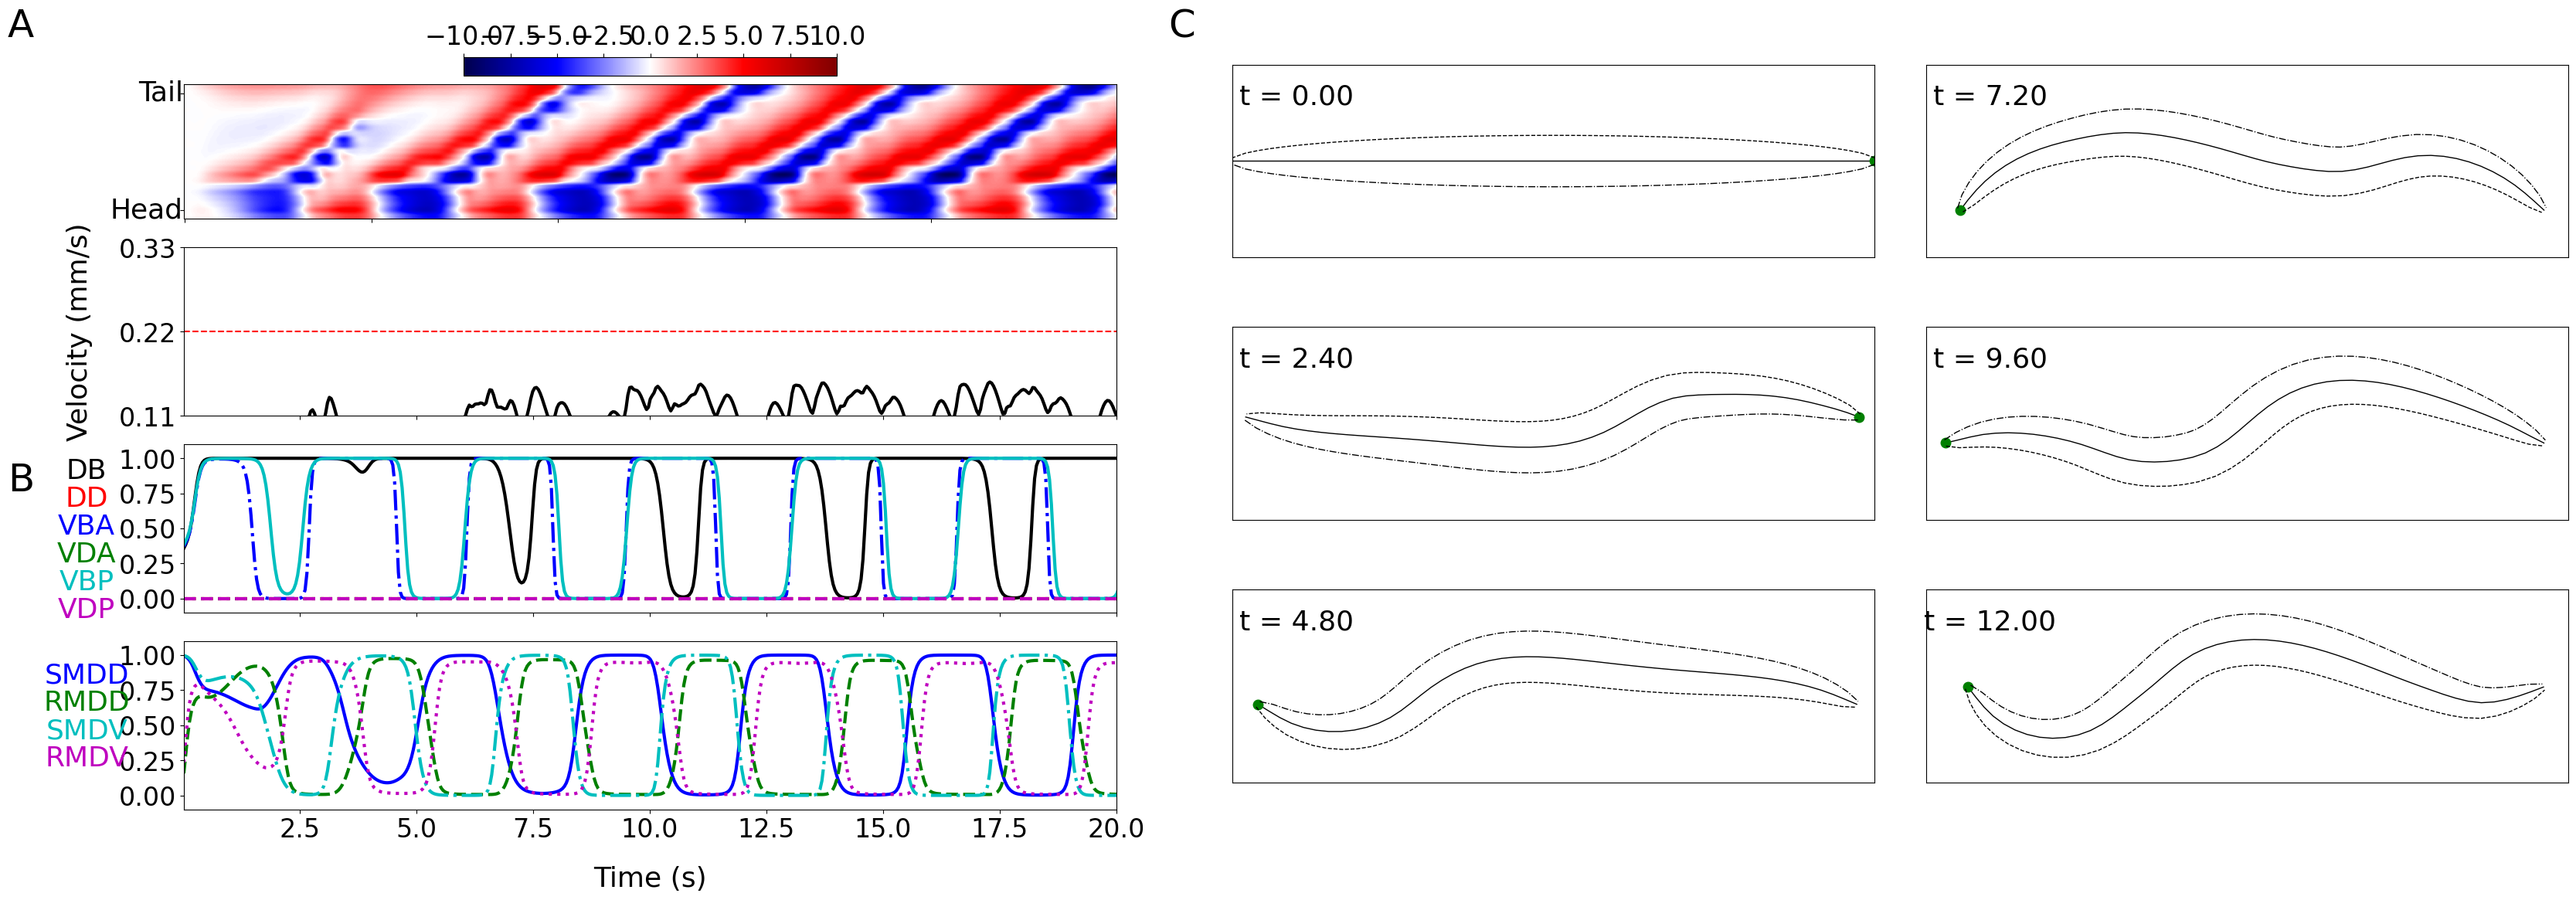

In [117]:
args['maxGens']=50 #run the optimization for ten more generations 
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)